# Minería de Datos - K Means

El objetivo es descubrir **perfiles de salud mental entre los diferentes Estados de EE.UU.**

**Preprocesamiento consiste en:**
Filtrar el dataset para aislar únicamente la entidad geográfica (`Group == 'By State'`).
Pivotaremos la tabla para que cada Estado sea una fila y los promedios históricos de sus indicadores sean las características.
Aplicaremos **Normalización (`StandardScaler`)**.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# carga
df = pd.read_csv("../data/Mental_Health_Clean_Final.csv")
df_states = df[df['Group'] == 'By State'].copy()

# promedio de cada indicador por estado
df_pivot = df_states.pivot_table(
    index='State',
    columns='Indicator',
    values='Value',
    aggfunc='mean'
).dropna()

X = df_pivot.values
estados = df_pivot.index.tolist()

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset listo. Estados a procesar: {X_scaled.shape[0]} | Características por estado: {X_scaled.shape[1]}")

Dataset listo. Estados a procesar: 51 | Características por estado: 4


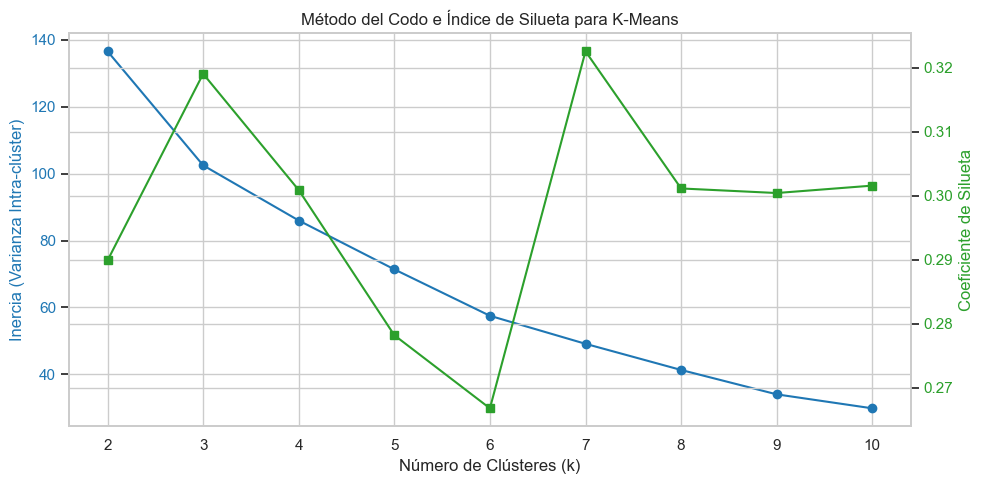

In [17]:
inercia = []
siluetas = []
rango_k = range(2, 11)

for k in rango_k:
    # K-Means
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)

    inercia.append(kmeans_temp.inertia_)
    siluetas.append(silhouette_score(X_scaled, labels_temp))

# evaluación de K
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Número de Clústeres (k)')
ax1.set_ylabel('Inercia (Varianza Intra-clúster)', color=color)
ax1.plot(rango_k, inercia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Coeficiente de Silueta', color=color)
ax2.plot(rango_k, siluetas, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Método del Codo e Índice de Silueta para K-Means')
fig.tight_layout()
plt.show()

## Modelo Final, Aplicación de Algoritmos Diferentes y Métricas
De acuerdo a la gráfica, seleccionaremos **$k=3$** (donde la inercia se estabiliza y la silueta tiene un buen pico).
Para cumplir con el **Criterio 4**, probaremos dos algoritmos:
1.  **K-Means (Basado en Centroides)**
2.  **Agglomerative Clustering (Jerárquico)**

Luego, evaluaremos los resultados del modelo principal (K-Means) usando métricas avanzadas (Criterio 3):
*   **Coeficiente de Silueta:** Rango [-1, 1]. Cercano a 1 indica clústeres bien separados.
*   **Índice Davies-Bouldin:** Mide la similitud promedio entre clústeres. **Valores más bajos son mejores**.
*   **Índice Calinski-Harabasz:** Evalúa la relación de dispersión entre clústeres vs dispersión intra-clúster. **Valores más altos son mejores**.
Celda 6 (Código Python)

MÉTRICAS DE EVALUACIÓN (K-MEANS)
Coeficiente de Silueta:   0.3190 (Positivo = buena cohesión)
Índice Davies-Bouldin:    1.1010 (Bajo = mejor separación)
Índice Calinski-Harabasz: 23.7741 (Alto = clústeres densos y separados)



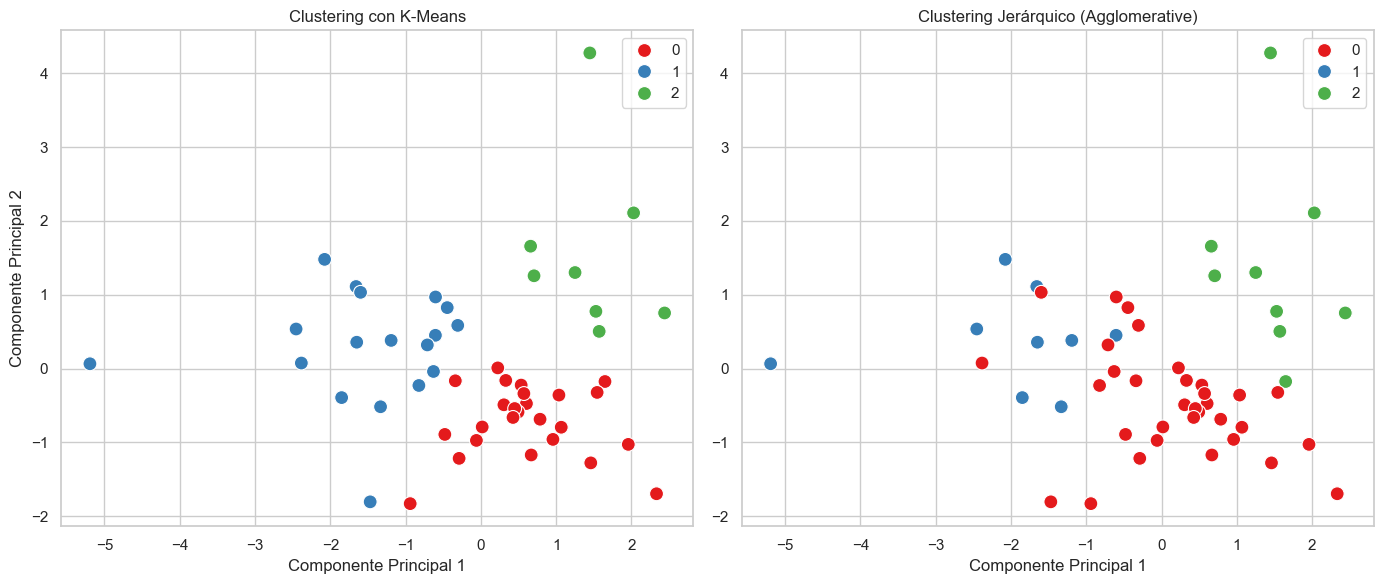

In [18]:
k_optimo = 3

# K-Means model
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

# Agglomerative model
hc_modelo = AgglomerativeClustering(n_clusters=k_optimo, linkage='ward')
labels_hc = hc_modelo.fit_predict(X_scaled)

# cálculo de métricas
sil = silhouette_score(X_scaled, labels_kmeans)
db = davies_bouldin_score(X_scaled, labels_kmeans)
ch = calinski_harabasz_score(X_scaled, labels_kmeans)

print("MÉTRICAS DE EVALUACIÓN (K-MEANS)")
print(f"Coeficiente de Silueta:   {sil:.4f} (Positivo = buena cohesión)")
print(f"Índice Davies-Bouldin:    {db:.4f} (Bajo = mejor separación)")
print(f"Índice Calinski-Harabasz: {ch:.4f} (Alto = clústeres densos y separados)\n")

# graficar las multidimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# visualización de Algoritmos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_kmeans, palette='Set1', s=100, ax=axes[0])
axes[0].set_title('Clustering con K-Means')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_hc, palette='Set1', s=100, ax=axes[1])
axes[1].set_title('Clustering Jerárquico (Agglomerative)')
axes[1].set_xlabel('Componente Principal 1')

plt.tight_layout()
plt.show()

df_pivot['Cluster'] = labels_kmeans

## 4. Interpretación y Análisis Crítico
Entenderemos las características naturales de los datos calculando el promedio de los indicadores originales para cada clúster.

In [19]:
resumen_cluster = df_pivot.groupby('Cluster').mean()

print("PERFIL PROMEDIO DE LOS CLÚSTERES ")
display(resumen_cluster)

# ejemplo de estados por cluster
for c in range(k_optimo):
    estados_en_cluster = df_pivot[df_pivot['Cluster'] == c].index.tolist()
    print(f"\nClúster {c} ({len(estados_en_cluster)} estados):")
    print(f"{estados_en_cluster[:5]}...")

PERFIL PROMEDIO DE LOS CLÚSTERES 


Indicator,"Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks","Received Counseling or Therapy, Last 4 Weeks","Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks","Took Prescription Medication for Mental Health, Last 4 Weeks"
Cluster,,,,
0,10.575996,9.396004,27.284970,24.523879
1,10.329324,9.955729,23.034680,19.500168
2,12.235303,13.567045,28.388636,23.165152



Clúster 0 (25 estados):
['Alabama', 'Arkansas', 'Idaho', 'Indiana', 'Iowa']...

Clúster 1 (18 estados):
['Alaska', 'Arizona', 'California', 'Connecticut', 'Delaware']...

Clúster 2 (8 estados):
['Colorado', 'District of Columbia', 'Massachusetts', 'Oregon', 'Rhode Island']...
